In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x) :
    return 3*x**2 -4*x +5

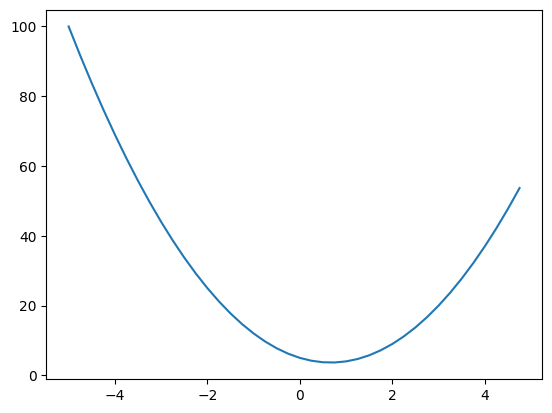

In [29]:
xs = np.arange(-5,5,0.25)
y = f(xs)
plt.plot(xs,y)

In [101]:
## derivative


def deri(temp) :
    h=0.00001
    return (f(temp+h)-f(temp))/h
    

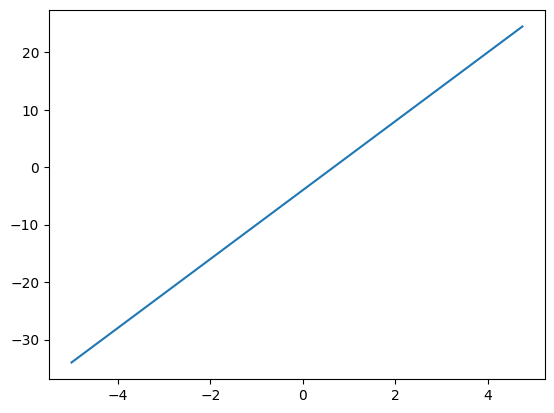

In [102]:
dy = deri(xs)
plt.plot(xs,dy)

In [103]:
print(xs[20])
dy[20]

0.0


np.float64(-3.999970000023722)

In [104]:
#lets get more complex
a=2
b=-3
c=10
d=a*b +c
print(d)


4


In [107]:
h=0.001
d2=(a+h)*b+c
print((d2-d)/h)

-3.0000000000001137


In [22]:
class Value :
    def __init__(self,data,_children =(),_op='',label='',grad=0) :
        self.data = data
        self._prev=set(_children)
        self._op=_op
        self.label=label
        self.grad=grad
    def __repr__(self) :
        return f"Value(data={self.data})"
    def __add__(self,other) :
        out = Value(self.data + other.data,(self,other),'+')
        return out
    def __mul__(self,other) :
        out = Value(self.data*other.data,(self,other),'*')
        return out

In [23]:
a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c= Value(10.0,label='c')
e=a*b; e.label='e'
d = e+c;d.label='d'
f= Value(-2.0, label='f')
L=d*f;L.label='L'

In [28]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f |grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


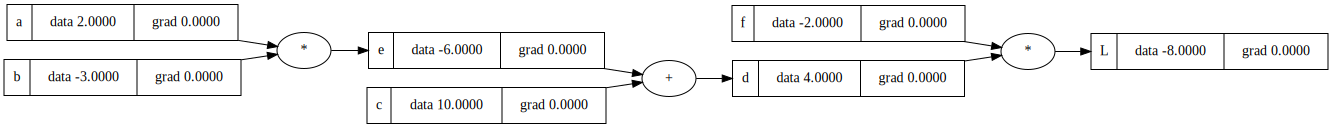

In [29]:
draw_dot(L)